In [1]:
#import the dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

#data collection and analysis

In [2]:
#loading the data from csv file
df = pd.read_csv('\\Users\\USER\\Desktop\\400 level\\Dataanalysis\\Linear regression project\\insurance.csv')

In [3]:
#first five rows of the data frame
df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
#number of rows and columns in the data det
df.shape

(1338, 7)

In [5]:
#infomation about the data set
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Categorical features
sex
smoker
region


In [6]:
#check for missing vallues
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Exploratory analysis

In [7]:
#statiscal measures about the data set
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


C:\Users\USER\AppData\Local\Temp\ipykernel_376\1393291409.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["age"],hist=True)


Text(0.5, 1.0, 'Age Distribution')

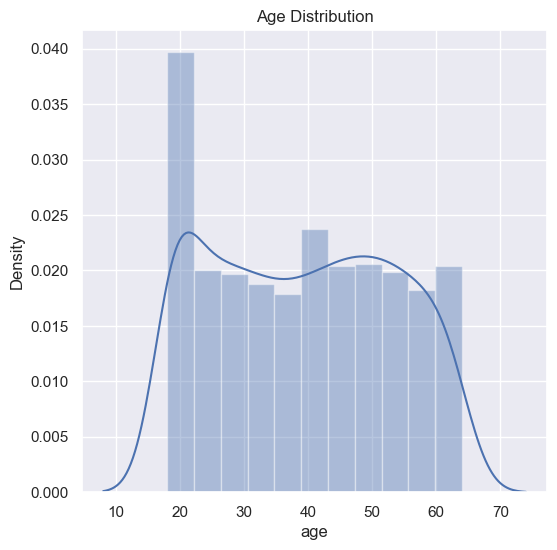

In [8]:
#distribution of age value
sns.set()
plt.figure(figsize=(6,6))
sns.distplot(df["age"],hist=True)
plt.title('Age Distribution')
    
           

Text(0.5, 1.0, 'Sex Distribution')

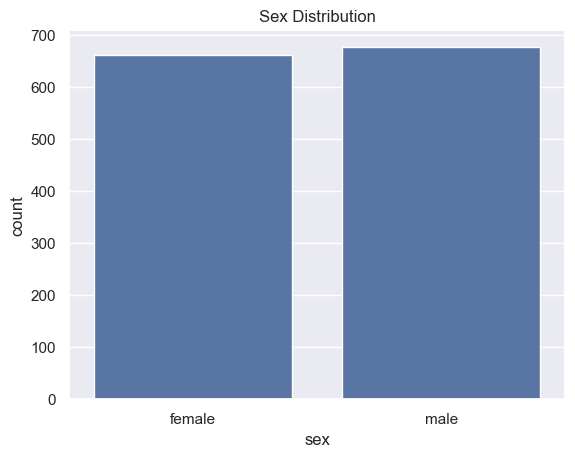

In [9]:
#Dist for gender column
sns.countplot(x="sex", data = df)
plt.title("Sex Distribution")

In [10]:
df["sex"].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

C:\Users\USER\AppData\Local\Temp\ipykernel_376\2006481186.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["bmi"])


Text(0.5, 1.0, 'BMI Distribution')

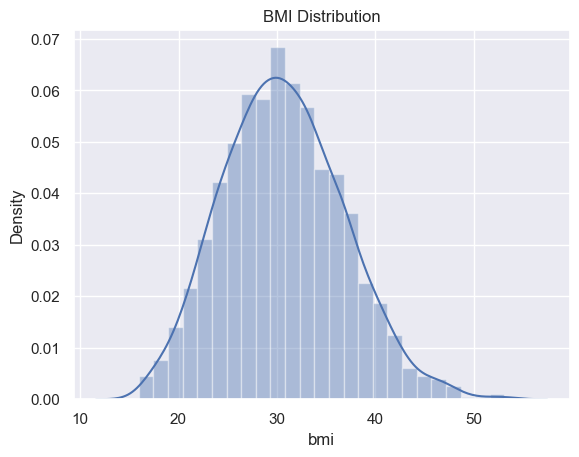

In [11]:
sns.distplot(df["bmi"])
plt.title("BMI Distribution")

Normal BMI range is - 18.5 to 24.9

<Axes: xlabel='children', ylabel='count'>

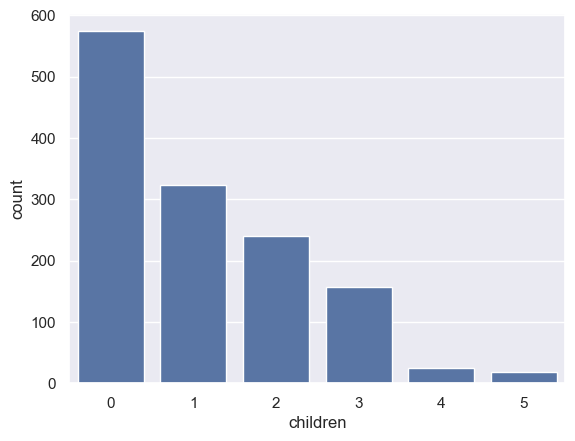

In [12]:
#children plot
sns.countplot(x="children", data=df)

In [13]:
df["children"].value_counts()

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

Text(0.5, 1.0, 'smoker')

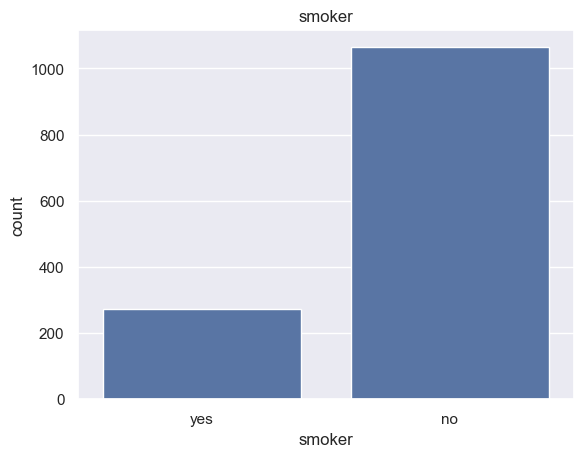

In [14]:
#smoker column
sns.countplot(x="smoker", data=df)
plt.title("smoker")


In [15]:
df["smoker"].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

<Axes: xlabel='region', ylabel='count'>

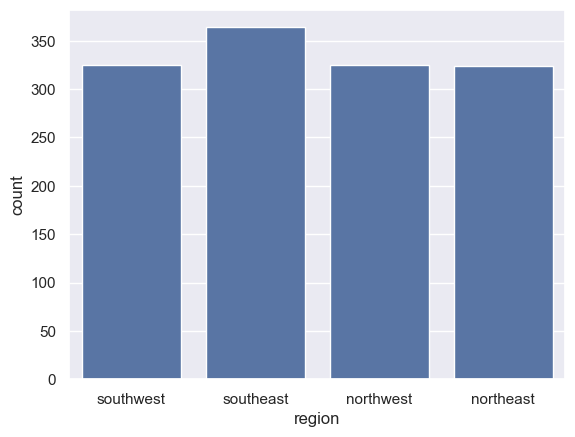

In [16]:
sns.countplot(x="region",data=df)

In [17]:
df["region"].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

C:\Users\USER\AppData\Local\Temp\ipykernel_376\3142352375.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["charges"])


Text(0.5, 1.0, 'Charge distribution')

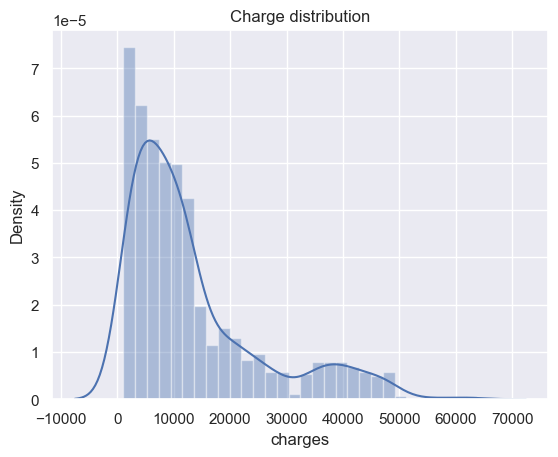

In [18]:
sns.distplot(df["charges"])
plt.title("Charge distribution")

Data pre Processing

In [19]:
#dv = pd.get_dummies(df["sex"])
#df= pd.concat([df,dv],axis=1)

In [20]:
df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [21]:
# encoding
df.replace({"sex":{"male":0,"female":1}},inplace=True)
df.replace({"smoker":{"yes":1,"no":0}},inplace=True)
df.replace({"region":{"southeast":0,"southwest":1,"northeast":2,"northwest":3,}},inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_376\3845884036.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"sex":{"male":0,"female":1}},inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_376\3845884036.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"smoker":{"yes":1,"no":0}},inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_376\3845884036.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly c

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   int64  
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 73.3 KB


In [23]:
df.corr()

,age,sex,bmi,children,smoker,region,charges
age,1.000000,0.020856,0.109272,0.042469,-0.025019,0.005212,0.299008
sex,0.020856,1.000000,-0.046371,-0.017163,-0.076185,0.016121,-0.057292
bmi,0.109272,-0.046371,1.000000,0.012759,0.003750,-0.261829,0.198341
children,0.042469,-0.017163,0.012759,1.000000,0.007673,0.019257,0.067998
smoker,-0.025019,-0.076185,0.003750,0.007673,1.000000,-0.053930,0.787251
region,0.005212,0.016121,-0.261829,0.019257,-0.053930,1.000000,-0.056993
charges,0.299008,-0.057292,0.198341,0.067998,0.787251,-0.056993,1.000000


<Axes: >

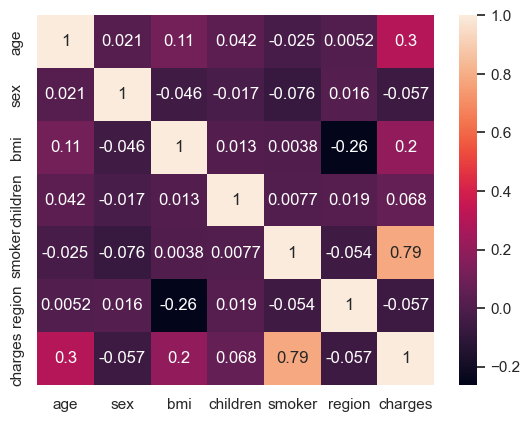

In [24]:
sns.heatmap(df.corr(),annot = True)

In [25]:
x = df.drop(columns="charges", axis =1)
y = df["charges"]

In [26]:
x

,age,sex,bmi,children,smoker,region
0,19,1,27.900,0,1,1
1,18,0,33.770,1,0,0
2,28,0,33.000,3,0,0
3,33,0,22.705,0,0,3
4,32,0,28.880,0,0,3
...,...,...,...,...,...,...
1333,50,0,30.970,3,0,3
1334,18,1,31.920,0,0,2
1335,18,1,36.850,0,0,0
1336,21,1,25.800,0,0,1


In [27]:
y

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

splitting data ino training and testing

In [28]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=2)


In [29]:
x_train.shape

(1070, 6)

In [30]:
x_test.shape

(268, 6)

In [31]:
y_train.shape

(1070,)

In [32]:
y_test.shape

(268,)

model training

In [33]:
#loading the linear regression model
lr = LinearRegression()

In [34]:
lr.fit(x_train,y_train)


LinearRegression()

MODEL EVALUATION

In [35]:
ypre= lr.predict(x_train)

In [37]:
lr.score(x_train,y_train)

0.751505643411174

In [38]:
#r^2 value
r2= metrics.r2_score(y_train,ypre)
r2

0.751505643411174

In [41]:
lr.score(x_test,y_test)

0.7447273869684076

In [45]:
#test value prediction and r2 value
ypretest = lr.predict(x_test)
r2test = metrics.r2_score(y_test,ypretest)
r2test

0.7447273869684076

Building a Predictive System


In [47]:
ind=(31,1,25.74,0,0,0)
ind = np.array(ind)
ind = ind.reshape(1,-1)
pre = lr.predict(ind)
pre

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3760.0805765])